# ch286 — Bayesian Statistics

*(Applies Bayes' theorem from ch246; connects to prior knowledge and posterior updates)*

## 1. The Bayesian View

Frequentist statistics treats parameters as fixed unknowns. Bayesian statistics treats parameters as random variables with probability distributions that encode uncertainty.

Before seeing data, you have a **prior** belief about a parameter $\theta$. After seeing data $D$, you update to a **posterior**:

$$\underbrace{P(\theta \mid D)}_{\text{posterior}} = \frac{\underbrace{P(D \mid \theta)}_{\text{likelihood}} \cdot \underbrace{P(\theta)}_{\text{prior}}}{\underbrace{P(D)}_{\text{normalizer}}}$$

*(Bayes' theorem was introduced in ch246.)*

The posterior is the complete answer: it is a distribution over all plausible parameter values given your data and prior beliefs.

---

## 2. Beta-Binomial: Bayesian A/B Testing

P(treatment > control): 0.8651
Expected lift:          +0.0150
95% credible interval:  [-0.0118, +0.0418]


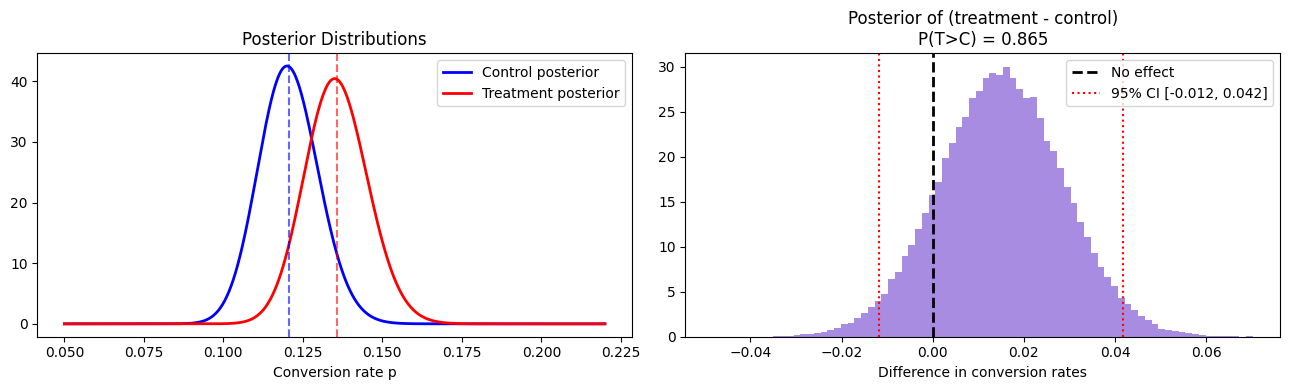

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

# Beta distribution: conjugate prior for binomial likelihood
# Prior: Beta(alpha, beta) encodes prior belief about conversion rate p
# Posterior: Beta(alpha + successes, beta + failures) -- exact, closed form

def bayesian_ab_test(
    n_control:   int, k_control:   int,   # trials, successes
    n_treatment: int, k_treatment: int,
    prior_alpha: float = 1.0,             # Beta(1,1) = uniform prior
    prior_beta:  float = 1.0,
    n_samples:   int   = 100_000,
    rng = None,
) -> dict:
    """
    Bayesian comparison of two conversion rates.
    Uses Beta-Binomial conjugate model.
    Returns posterior samples and probability that treatment > control.
    """
    if rng is None: rng = np.random.default_rng()

    # Posterior parameters
    a_c = prior_alpha + k_control
    b_c = prior_beta  + (n_control - k_control)
    a_t = prior_alpha + k_treatment
    b_t = prior_beta  + (n_treatment - k_treatment)

    # Sample from posteriors
    samples_c = rng.beta(a_c, b_c, n_samples)
    samples_t = rng.beta(a_t, b_t, n_samples)

    prob_treatment_wins = np.mean(samples_t > samples_c)
    expected_lift       = np.mean(samples_t - samples_c)

    # 95% credible interval for the difference
    diff_samples = samples_t - samples_c
    ci_lo, ci_hi = np.percentile(diff_samples, [2.5, 97.5])

    return {
        'posterior_control':   (a_c, b_c),
        'posterior_treatment': (a_t, b_t),
        'samples_c':   samples_c,
        'samples_t':   samples_t,
        'prob_t_wins': prob_treatment_wins,
        'expected_lift': expected_lift,
        'credible_interval_95': (ci_lo, ci_hi),
    }


# Example: 1200 control, 144 conversions (12%)
#          1200 treatment, 162 conversions (13.5%)
result = bayesian_ab_test(
    n_control=1200,   k_control=144,
    n_treatment=1200, k_treatment=162,
    rng=rng
)

print(f"P(treatment > control): {result['prob_t_wins']:.4f}")
print(f"Expected lift:          {result['expected_lift']:+.4f}")
print(f"95% credible interval:  [{result['credible_interval_95'][0]:+.4f}, "
      f"{result['credible_interval_95'][1]:+.4f}]")

# Visualize posteriors
x = np.linspace(0.05, 0.22, 500)
a_c, b_c = result['posterior_control']
a_t, b_t = result['posterior_treatment']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(x, stats.beta.pdf(x, a_c, b_c), 'b-', lw=2, label='Control posterior')
ax.plot(x, stats.beta.pdf(x, a_t, b_t), 'r-', lw=2, label='Treatment posterior')
ax.axvline(a_c/(a_c+b_c), color='blue', ls='--', alpha=0.6)
ax.axvline(a_t/(a_t+b_t), color='red',  ls='--', alpha=0.6)
ax.set_xlabel('Conversion rate p')
ax.set_title('Posterior Distributions')
ax.legend()

ax = axes[1]
diff = result['samples_t'] - result['samples_c']
ax.hist(diff, bins=80, color='mediumpurple', edgecolor='none', density=True, alpha=0.8)
ax.axvline(0, color='black', lw=2, ls='--', label='No effect')
lo, hi = result['credible_interval_95']
ax.axvline(lo, color='red', lw=1.5, ls=':', label=f'95% CI [{lo:.3f}, {hi:.3f}]')
ax.axvline(hi, color='red', lw=1.5, ls=':')
pwin = result['prob_t_wins']
ax.fill_between(
    np.linspace(lo, hi, 100),
    np.zeros(100), np.interp(np.linspace(lo, hi, 100),
                              np.sort(diff),
                              np.linspace(0, 1, len(diff))), alpha=0
)
ax.set_title(f'Posterior of (treatment - control)\nP(T>C) = {pwin:.3f}')
ax.set_xlabel('Difference in conversion rates')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Prior Sensitivity

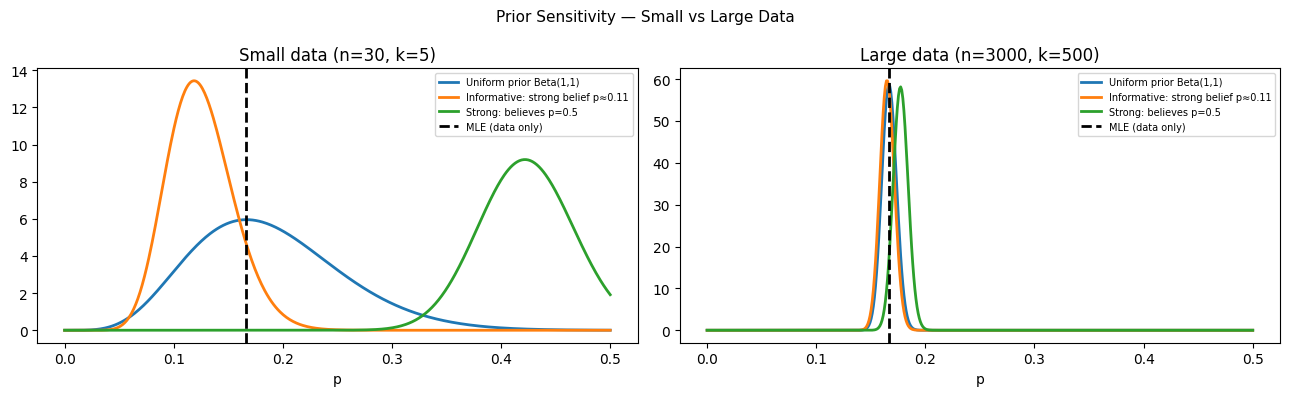

With 30 obs: posteriors differ substantially across priors.
With 3000 obs: posteriors converge regardless of prior.


In [2]:
# How much does the prior affect the posterior?
# Large data: prior barely matters. Small data: prior dominates.

priors = [
    (1, 1,   'Uniform prior Beta(1,1)'),
    (10, 80, 'Informative: strong belief p≈0.11'),
    (50, 50, 'Strong: believes p=0.5'),
]

# Small experiment: 30 obs, 5 successes
n_obs, k_obs = 30, 5

x = np.linspace(0, 0.5, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, n_data, k_data, title in [
    (axes[0], 30, 5, f'Small data (n={30}, k={5})'),
    (axes[1], 3000, 500, f'Large data (n={3000}, k={500})'),
]:
    for a_p, b_p, label in priors:
        a_post = a_p + k_data
        b_post = b_p + (n_data - k_data)
        ax.plot(x, stats.beta.pdf(x, a_post, b_post), lw=2, label=label)

    ax.axvline(k_data/n_data, color='black', ls='--', lw=2, label='MLE (data only)')
    ax.set_title(title); ax.set_xlabel('p'); ax.legend(fontsize=7)

plt.suptitle('Prior Sensitivity — Small vs Large Data', fontsize=11)
plt.tight_layout()
plt.show()

print("With 30 obs: posteriors differ substantially across priors.")
print("With 3000 obs: posteriors converge regardless of prior.")

## 4. Bayesian Updating Sequentially

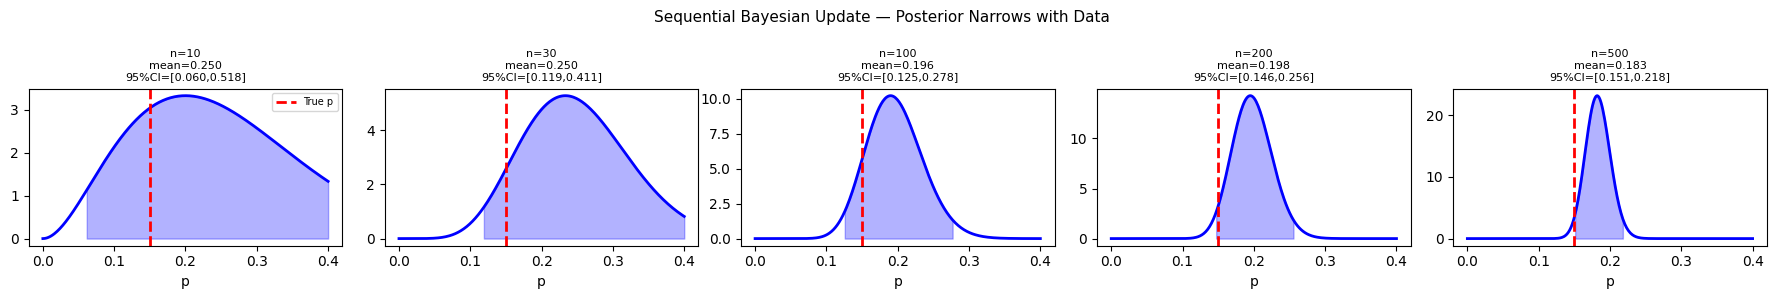

In [3]:
# Sequential Bayesian update: no peeking problem
# Posterior after n observations = prior for observation n+1

true_p = 0.15
n_total = 500
observations = rng.binomial(1, true_p, n_total)

# Track posterior mean and 95% CI over time
a, b_par = 1.0, 1.0  # uniform prior
check_ns = [10, 30, 100, 200, 500]

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
x = np.linspace(0, 0.4, 300)

k = 0
for i, ax in enumerate(axes):
    n_shown = check_ns[i]
    k = observations[:n_shown].sum()
    a_post = a + k
    b_post = b_par + (n_shown - k)
    post_mean = a_post / (a_post + b_post)
    ci = stats.beta.ppf([0.025, 0.975], a_post, b_post)

    ax.plot(x, stats.beta.pdf(x, a_post, b_post), 'b-', lw=2)
    ax.axvline(true_p, color='red', ls='--', lw=2, label='True p')
    ax.fill_between(x[(x>=ci[0]) & (x<=ci[1])],
                    stats.beta.pdf(x[(x>=ci[0]) & (x<=ci[1])], a_post, b_post),
                    alpha=0.3, color='blue')
    ax.set_title(f'n={n_shown}\nmean={post_mean:.3f}\n95%CI=[{ci[0]:.3f},{ci[1]:.3f}]', fontsize=8)
    ax.set_xlabel('p')
    if i == 0: ax.legend(fontsize=7)

plt.suptitle('Sequential Bayesian Update — Posterior Narrows with Data', fontsize=11)
plt.tight_layout()
plt.show()

## 5. What Comes Next

Bayesian statistics provides the framework. **ch287 — Information Theory** provides a complementary lens: instead of asking how uncertain we are about a parameter, it asks how much information a random variable carries. The two frameworks connect deeply: entropy (ch288) is the log of the number of bits needed to encode a distribution, and KL divergence (ch289) measures how much information is lost when using one distribution to approximate another — the same loss minimized during training of most ML models.